CH.SC.U4CSE23248 Sriraam Vairavan

In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
import kagglehub

path = kagglehub.dataset_download("omnamahshivai/surgical-dataset-binary-classification")
csv_path=path+'/Surgical-deepnet.csv'
data=pd.read_csv(csv_path)
data.head()

100%|██████████| 206k/206k [00:00<00:00, 71.6MB/s]

Extracting files...


,bmi,Age,asa_status,baseline_cancer,baseline_charlson,baseline_cvd,baseline_dementia,baseline_diabetes,baseline_digestive,baseline_osteoart,...,complication_rsi,dow,gender,hour,month,moonphase,mort30,mortality_rsi,race,complication
0,19.31,59.2,1,1,0,0,0,0,0,0,...,-0.57,3,0,7.63,6,1,0,-0.43,1,0
1,18.73,59.1,0,0,0,0,0,0,0,0,...,0.21,0,0,12.93,0,1,0,-0.41,1,0
2,21.85,59.0,0,0,0,0,0,0,0,0,...,0.00,2,0,7.68,5,3,0,0.08,1,0
3,18.49,59.0,1,0,1,0,0,1,1,0,...,-0.65,2,1,7.58,4,3,0,-0.32,1,0
4,19.70,59.0,1,0,0,0,0,0,0,0,...,0.00,0,0,7.88,11,0,0,0.00,1,0


In [3]:
X = data.drop('complication', axis=1)
y = data['complication']


removing last column since it is binary only not useful

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)



Shapes:
X_train: (11708, 24) y_train: (11708,)
X_test: (2927, 24) y_test: (2927,)


Linear Model

In [5]:
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

RPF Model

In [6]:
rbf_svm = SVC(kernel='rbf', gamma=0.5, C=1)
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)

**common function for evaluation metrics**

In [7]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    conf_mat = metrics.confusion_matrix(y_true, y_pred)
    accuracy = metrics.accuracy_score(y_true, y_pred)

    print("Confusion Matrix:\n", conf_mat)
    print("Accuracy Score:", accuracy)
    print("Accuracy Percentage:", int(accuracy * 100), "%")

    conf_df = pd.crosstab(y_true, y_pred, rownames=['Actual'], colnames=['Predicted'])
    sn.heatmap(conf_df, annot=True, cmap="Blues", fmt='g')
    plt.title(f"Confusion Matrix Heatmap - {model_name}")
    plt.show()

# Trying both to find out which is more suited for our question


--- Linear Kernel SVM ---
Confusion Matrix:
 [[2115  122]
 [ 452  238]]
Accuracy Score: 0.8038947728049197
Accuracy Percentage: 80 %


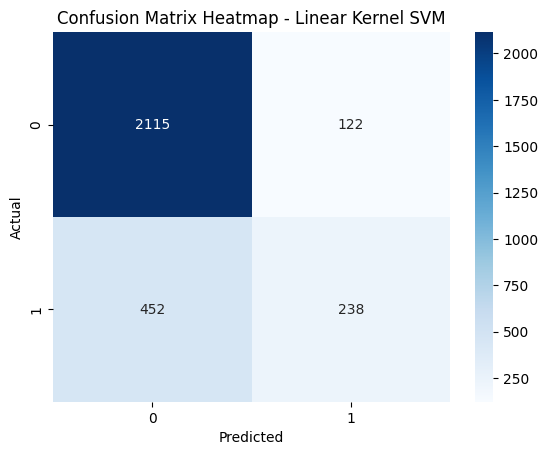


--- RBF Kernel SVM ---
Confusion Matrix:
 [[2237    0]
 [ 690    0]]
Accuracy Score: 0.7642637512811753
Accuracy Percentage: 76 %


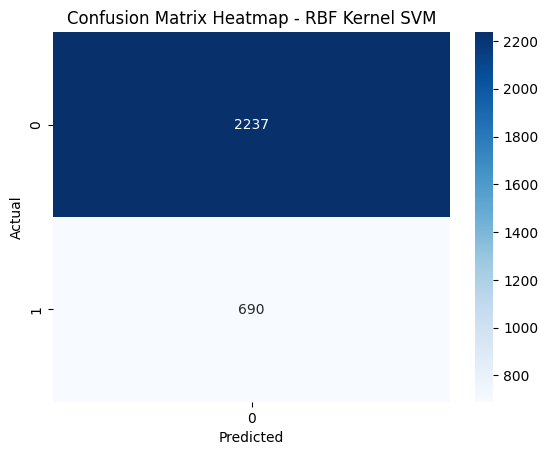

In [10]:
evaluate_model(y_test, y_pred_linear, "Linear Kernel SVM")
evaluate_model(y_test, y_pred_rbf, "RBF Kernel SVM")

In [9]:
linear_acc = metrics.accuracy_score(y_test, y_pred_linear)
rbf_acc = metrics.accuracy_score(y_test, y_pred_rbf)

print("\nComparison of Models:")
print("Linear Kernel Accuracy :", round(linear_acc * 100, 2), "%")
print("RBF Kernel Accuracy    :", round(rbf_acc * 100, 2), "%")

if rbf_acc > linear_acc:
    print("RBF Kernel performs better for this dataset.")
else:
    print("Linear Kernel performs better for this dataset.")


Comparison of Models:
Linear Kernel Accuracy : 80.39 %
RBF Kernel Accuracy    : 76.43 %
Linear Kernel performs better for this dataset.
